<a href="https://colab.research.google.com/github/aqilFauzi121/UTS-CPS/blob/main/UTS_CPS_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis dan Derivasi Kopel Induktor

Dokumentasi ini mencakup:
1. **Analisis KCL & KVL**  
2. **Persamaan State-Space**  
3. **Transfer Function**  
4. **Penentuan $L_1$ & $L_2$**  
5. **Respon Frekuensi & Waktu**  

In [26]:
# === 1. Analisis dan Derivasi Kopel Induktor ===
import sympy as sp

# Definisi simbol
L1, L2, k = sp.symbols('L1 L2 k', positive=True)
R1, R2, Rload, Rs = sp.symbols('R1 R2 Rload Rs', positive=True)

# Mutual inductance M = k * sqrt(L1*L2)
M = k * sp.sqrt(L1 * L2)

sp.pretty_print(M)

  ____   ____  
╲╱ L₁ ⋅╲╱ L₂ ⋅k


# 1. Analisis Hukum Tegangan Kirchhoff

Rangkaian ini terdiri dari dua loop kopel:

- **Rangkaian primer**: sumber tegangan $U_S$, resistor $R_1$, induktor $L_1$  
- **Rangkaian sekunder**: resistor $R_2$, induktor $L_2$, resistor beban $R_{\mathrm{Load}}$

## KVL pada rangkaian primer

$
U_S = i_1 R_1 + L_1 \frac{d i_1}{d t} \;+\; M \frac{d i_2}{d t}
$

## KVL pada rangkaian sekunder

$
0 = i_2 R_2 + L_2 \frac{d i_2}{d t} \;+\; M \frac{d i_1}{d t} \;+\; i_2 R_{\mathrm{Load}}
$


Induktansi mutual \(M\) berkaitan dengan koefisien kopel \(k\):

$
M = k \sqrt{L_1 L_2}
$

di mana nilai \(k\) berkisar antara 0.1 hingga 0.9, yang mewakili kekuatan kopel antara kedua induktor.


## 2. State Space Analysis

Untuk representasi ruang keadaan, kita identifikasi variabel keadaan sebagai arus pada induktor $i_1$ dan $i_2$.

Pertama, susun ulang persamaan KVL untuk memisahkan turunan:

$
L_1 \frac{d i_1}{d t} + M \frac{d i_2}{d t} = U_S - i_1 R_1
$
$
M \frac{d i_1}{d t} + L_2 \frac{d i_2}{d t} = -\,i_2\,(R_2 + R_{\mathrm{Load}})
$

Kemudian tulis dalam bentuk matriks:

$
\begin{bmatrix}
L_1 & M\\[0.5em]
M   & L_2
\end{bmatrix}
\begin{bmatrix}
\dot{i}_1\\[0.3em]
\dot{i}_2
\end{bmatrix}
=
\begin{bmatrix}
U_S - i_1 R_1\\[0.3em]
-\,i_2\,(R_2 + R_{\mathrm{Load}})
\end{bmatrix}
$

Menyelesaikan untuk turunan:

$
\begin{bmatrix}
\dot{i}_1\\[0.3em]
\dot{i}_2
\end{bmatrix}
=
\begin{bmatrix}
L_1 & M\\[0.5em]
M   & L_2
\end{bmatrix}^{-1}
\begin{bmatrix}
U_S - i_1 R_1\\[0.3em]
-\,i_2\,(R_2 + R_{\mathrm{Load}})
\end{bmatrix}
$

Determinannya:

$
\Delta = L_1 L_2 - M^2
$

Sehingga invers matriks induktansi:

$
\begin{bmatrix}
L_1 & M\\[0.5em]
M   & L_2
\end{bmatrix}^{-1}
=
\frac{1}{L_1 L_2 - M^2}
\begin{bmatrix}
L_2 & -M\\[0.5em]
-\,M & L_1
\end{bmatrix}
$

Dari rumus tersebut, didapatkan ekspresi turunan

$
\frac{d i_1}{d t}
=
\frac{L_2\,(U_S - i_1 R_1)\;+\;M\,i_2\,(R_2 + R_{\mathrm{Load}})}
{L_1 L_2 - M^2}
$

$
\frac{d i_2}{d t}
=
\frac{-\,M\,(U_S - i_1 R_1)\;-\;L_1\,i_2\,(R_2 + R_{\mathrm{Load}})}
{L_1 L_2 - M^2}
$

Dan dalam bentuk state-space standar

$
\begin{bmatrix}
\dot{i}_1 \\[0.5em]
\dot{i}_2
\end{bmatrix}
=
\underbrace{\frac{1}{L_1 L_2 - M^2}
\begin{bmatrix}
-\,R_1 L_2 & M\,(R_2 + R_{\mathrm{Load}}) \\[0.5em]
\;M R_1   & -\,L_1\,(R_2 + R_{\mathrm{Load}})
\end{bmatrix}}_{A}
\;
\begin{bmatrix}
i_1 \\[0.3em]
i_2
\end{bmatrix}
+
\underbrace{\frac{1}{L_1 L_2 - M^2}
\begin{bmatrix}
L_2 \\[0.3em]
-\,M
\end{bmatrix}}_{B}
\;U_S
$

Sehingga diperoleh representasi:

$
\dot{x} = A\,x + B\,u
$

dengan:
- $x = \bigl[i_1,\;i_2\bigr]^\mathsf{T}$ vektor keadaan  
- $A$ matriks sistem  
- $B$ matriks input  
- $u = U_S$ input  


In [27]:
# === 2. Persamaan State‐Space dan Karakteristik ===
s = sp.symbols('s')

# Denominator (persamaan karakteristik)
den = (
    s**2 * (L1*L2 - M**2)
  + s * (L1*R2 + L1*Rload + L2*R1 + L2*Rs)
  + (R1*R2 + R1*Rload + R2*Rs + Rload*Rs)
)

# Matriks L dan inversinya
Lmat = sp.Matrix([[L1, M],
                  [M,  L2]])
Linv = sp.simplify(Lmat.inv())

# Matriks A dan B (state‐space)
A = Linv * sp.Matrix([[-R1,   -Rs],
                      [-Rs, -(R2+Rload)]])
B = Linv * sp.Matrix([1, 0])

print("L-matrix:")
sp.pretty_print(Lmat)
print("\nL-inverse:")
sp.pretty_print(Linv)
print("\nState matrix A:")
sp.pretty_print(A)
print("\nInput matrix B:")
sp.pretty_print(B)

L-matrix:
⎡                   ____   ____  ⎤
⎢      L₁         ╲╱ L₁ ⋅╲╱ L₂ ⋅k⎥
⎢                                ⎥
⎢  ____   ____                   ⎥
⎣╲╱ L₁ ⋅╲╱ L₂ ⋅k        L₂       ⎦

L-inverse:
⎡         -1                       k           ⎤
⎢     ───────────        ──────────────────────⎥
⎢        ⎛ 2    ⎞          ____   ____ ⎛ 2    ⎞⎥
⎢     L₁⋅⎝k  - 1⎠        ╲╱ L₁ ⋅╲╱ L₂ ⋅⎝k  - 1⎠⎥
⎢                                              ⎥
⎢          k                      -1           ⎥
⎢──────────────────────       ───────────      ⎥
⎢  ____   ____ ⎛ 2    ⎞          ⎛ 2    ⎞      ⎥
⎣╲╱ L₁ ⋅╲╱ L₂ ⋅⎝k  - 1⎠       L₂⋅⎝k  - 1⎠      ⎦

State matrix A:
⎡    R₁                 Rs⋅k                Rs           k⋅(-R₂ - Rload)     ⎤
⎢─────────── - ──────────────────────   ─────────── + ────────────────────── ⎥
⎢   ⎛ 2    ⎞     ____   ____ ⎛ 2    ⎞      ⎛ 2    ⎞     ____   ____ ⎛ 2    ⎞ ⎥
⎢L₁⋅⎝k  - 1⎠   ╲╱ L₁ ⋅╲╱ L₂ ⋅⎝k  - 1⎠   L₁⋅⎝k  - 1⎠   ╲╱ L₁ ⋅╲╱ L₂ ⋅⎝k  - 1⎠ ⎥
⎢                            

## 3. Transfer Function

Untuk menurunkan Transfer Function, kita terapkan transformasi Laplace pada persamaan KVL:

$
U_S(s) = I_1(s)\,R_1 + sL_1\,I_1(s) + sM\,I_2(s)
$
$
0 = I_2(s)\,[R_2 + sL_2 + R_{\mathrm{Load}}] + sM\,I_1(s)
$

Dari persamaan kedua:

$
I_2(s) = \frac{-\,sM\,I_1(s)}{R_2 + sL_2 + R_{\mathrm{Load}}}
$

Substitusi ke persamaan pertama:

$
U_S(s)
= I_1(s)\,(R_1 + sL_1)
\;+\;sM\;\frac{-\,sM\,I_1(s)}{R_2 + sL_2 + R_{\mathrm{Load}}}
$
$
U_S(s)
= I_1(s)\,\Bigl(R_1 + sL_1\Bigr)
\;-\;\frac{s^2 M^2}{R_2 + sL_2 + R_{\mathrm{Load}}}\;I_1(s)
$
$
U_S(s)
= I_1(s)\;\Biggl[\;(R_1 + sL_1)
\;-\;\frac{s^2 M^2}{R_2 + sL_2 + R_{\mathrm{Load}}}\Biggr]
$

Maka fungsi transfer dari tegangan input ke arus primer adalah:

$
G_S(s) \;=\; \frac{I_1(s)}{U_S(s)}
\;=\;
\frac{1}
{(R_1 + sL_1)\;-\;\dfrac{s^2 M^2}{R_2 + sL_2 + R_{\mathrm{Load}}}}
$

Mencari penyebut umum
$
G_{S}(s)
=
\frac{R_{2} + sL_{2} + R_{\mathrm{Load}}}
{\;(R_{1} + sL_{1})(R_{2} + sL_{2} + R_{\mathrm{Load}})\;-\;s^{2}M^{2}\;}
$

Perluasan
$
G_{S}(s)
=
\frac{R_{2} + sL_{2} + R_{\mathrm{Load}}}
{%
R_{1}R_{2}
\;+\;
R_{1}R_{\mathrm{Load}}
\;+\;
sL_{1}R_{2}
\;+\;
sL_{1}R_{\mathrm{Load}}
\;+\;
sL_{2}R_{1}
\;+\;
sL_{2}R_{\mathrm{Load}}
\;+\;
s^{2}L_{1}L_{2}
\;-\;
s^{2}M^{2}
}
$

Penyusunan ulang (dengan $R_{S}$ sebagai resistor sumber dan $R_{\mathrm{Load}}$ sebagai beban)
$
G_{S}(s)
=
\frac{R_{2} + sL_{2} + R_{\mathrm{Load}}}
{%
R_{1}R_{2}
\;+\;
R_{1}R_{\mathrm{Load}}
\;+\;
R_{2}R_{S}
\;+\;
R_{\mathrm{Load}}R_{S}
\;+\;
s^{2}(L_{1}L_{2} - M^{2})
\;+\;
s\bigl(L_{1}R_{2} + L_{1}R_{\mathrm{Load}} + L_{2}R_{1} + L_{2}R_{S}\bigr)
}
$

Transfer Function arus beban <br>
$
G_{L}(s)
=
\frac{I_{2}(s)}{U_{S}(s)}
=
\frac{-\,sM}{(R_{1} + sL_{1})(R_{2} + sL_{2} + R_{\mathrm{Load}})\;-\;s^{2}M^{2}}
$

Transfer Function tegangan beban <br>
$
G_{V_{L}}(s)
=
I_{2}(s)\,R_{\mathrm{Load}}
=
R_{\mathrm{Load}}\;G_{L}(s)
$

$
G_{V_{L}}(s)
=
\frac{-\,sM\;R_{\mathrm{Load}}}
{(R_{1} + sL_{1})(R_{2} + sL_{2} + R_{\mathrm{Load}})\;-\;s^{2}M^{2}}
$

Simplifikasi Akhir

$
G_L(s)
=
\frac{M\,R_L\,s}
{R_1 R_2 \;+\; R_1 R_L \;+\; R_2 R_S \;+\; R_L R_S
\;+\; s^2\,(L_1 L_2 - M^2)\;+\; s\,(L_1 R_2 + L_1 R_L + L_2 R_1 + L_2 R_S)}
$

$
G_S(s)
=
\frac{R_S\,\bigl(-\,L_2 s \;-\; R_2 \;-\; R_L\bigr)}
{R_1 R_2 \;+\; R_1 R_L \;+\; R_2 R_S \;+\; R_L R_S
\;+\; s^2\,(L_1 L_2 - M^2)\;+\; s\,(L_1 R_2 + L_1 R_L + L_2 R_1 + L_2 R_S)}
$



In [28]:
# === 3. Transfer Function I1/US ===
I1, I2, US = sp.symbols('I1 I2 US')

# Dua KVL di domain s
eq1 = sp.Eq(US,   I1*(R1 + s*L1) + s*M*I2)
eq2 = sp.Eq(0,    I2*(R2 + Rload + s*L2) + s*M*I1)

sol = sp.solve([eq1, eq2], [I1, I2])
G_s = sp.simplify(sol[I1] / US)

print("Transfer function I1/US:")
sp.pretty_print(G_s)

Transfer function I1/US:
                             L₂⋅s + R₂ + Rload                              
────────────────────────────────────────────────────────────────────────────
         2  2          2                                                    
- L₁⋅L₂⋅k ⋅s  + L₁⋅L₂⋅s  + L₁⋅R₂⋅s + L₁⋅Rload⋅s + L₂⋅R₁⋅s + R₁⋅R₂ + R₁⋅Rload


# 4. Menentukan Nilai $L_1$ dan $L_2$

Dari papan tulis, kita tahu bahwa:
$
L_1 \;=\; \frac{1}{2}\,L_2
$

Menurut grafik respons frekuensi, nilai-nilai parameter adalah:

- Frekuensi resonansi pertama:  
  $
    f_1 = 100\ \mathrm{kHz},\quad k = 0{,}6
  $
- Frekuensi resonansi kedua:  
  $
    f_2 = 200\ \mathrm{kHz},\quad k = 0{,}6
  $
- Resistansi primer:  
  $
    R_1 = 1{,}2\ \Omega
  $
- Resistansi sekunder:  
  $
    R_2 = 1{,}6\ \Omega
  $
- Resistansi beban:  
  $
    R_{\mathrm{Load}} = 1000\ \Omega
  $

## 4.1 Persamaan Karakteristik

Penyebut (denominator) fungsi transfer memberikan persamaan karakteristik sistem:
$
s^2 \bigl(L_1 L_2 - M^2\bigr)
\;+\;
s \bigl(L_1 R_2 + L_1 R_{\mathrm{Load}} + L_2 R_1 + L_2 R_S \bigr)
\;+\;
\bigl(R_1 R_2 + R_1 R_{\mathrm{Load}} + R_2 R_S + R_{\mathrm{Load}} R_S \bigr)
= 0
$

Untuk kondisi resonansi, substitusi \(s = j\omega\) dan kita cari \(\omega\) di mana bagian imajiner sama dengan nol.

## 4.2 Hubungan Mutual Inductance

Diketahui:
$
L_1 = \tfrac12 L_2,
\qquad
M = k\,\sqrt{L_1 L_2}
     = k\,\sqrt{\tfrac12 L_2 \cdot L_2}
     = k\,\frac{L_2}{\sqrt{2}}
$
Dengan $k = 0{,}6$ maka:
$
M = 0{,}6\,\frac{L_2}{\sqrt2}
    = 0{,}424\,L_2
$

## 4.3 Frekuensi Sudut

Hitung frekuensi sudut:
$
\omega_1 = 2\pi\,f_1 = 2\pi \times 100\,000 = 628\,318{,}5\ \mathrm{rad/s}
$
$
\omega_2 = 2\pi\,f_2 = 2\pi \times 200\,000 = 1\,256\,637\ \mathrm{rad/s}
$

## 4.4 Substitusi dan Penyelesaian

Selanjutnya, substitusikan nilai $\omega_1$ dan $\omega_2$ ke dalam persamaan karakteristik (bagian imajiner) untuk mendapatkan dua persamaan yang dapat diselesaikan secara numerik/analitik guna menentukan $L_1$ dan $L_2$.

Proses penyelesaian dapat dilakukan dengan software aljabar simbolik atau dengan manipulasi manual untuk mendapatkan nilai akhir $L_2$, kemudian $L_1 = \tfrac12 L_2$.

In [29]:
# === 4. Cek Resonansi dengan Nilai Nyata ===
# 4.1 Parameter numerik
param_vals = {
    k:      0.6,
    R1:     1.2,
    R2:     1.6,
    Rload:  1e3,   # 1 kΩ
    Rs:     0.0
}

# 4.2 Bentuk M dan denominator lengkap
M_expr    = k * sp.sqrt(L1 * L2)
den_full  = den.subs(M, M_expr)

# 4.3 Substitusi numeric & s = jω
omega     = sp.symbols('omega', real=True)
den_jw    = den_full.subs(param_vals).subs(s, sp.I*omega)
imag_part = sp.simplify(sp.im(den_jw))

# 4.4 Frekuensi sudut
f1, f2    = 100e3, 200e3
w1, w2    = 2*sp.pi*f1, 2*sp.pi*f2

# 4.5 Cek Im{den(jω)} dengan L1,L2 hasil SPICE
L1_val, L2_val = 63.46e-6, 29.2e-6

res1 = imag_part.subs({omega: w1, L1:L1_val, L2:L2_val})
res2 = imag_part.subs({omega: w2, L1:L1_val, L2:L2_val})

print(f"Im[den(jω₁)] = {sp.N(res1):.3e}")
print(f"Im[den(jω₂)] = {sp.N(res2):.3e}")

Im[den(jω₁)] = 3.996e+4
Im[den(jω₂)] = 7.992e+4


## 5. Respon Frekuensi

Di bagian ini kita akan memplot **Bode plot** (magnitudo & fase) dari fungsi transfer $G(s)$ pada rentang 10 kHz-1 MHz, dengan parameter:
$
k = 0.6,\quad R_1 = 1.2\,\Omega,\quad R_2 = 1.6\,\Omega,\quad R_{\rm Load}=1\,\text{k}\Omega,\quad L_1=63.46\,\mu\mathrm{H},\quad L_2=29.2\,\mu\mathrm{H}.
$

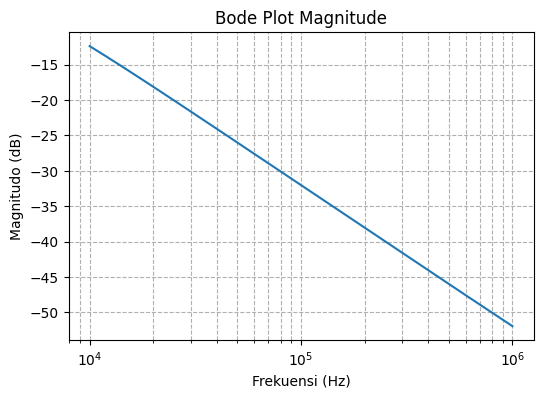

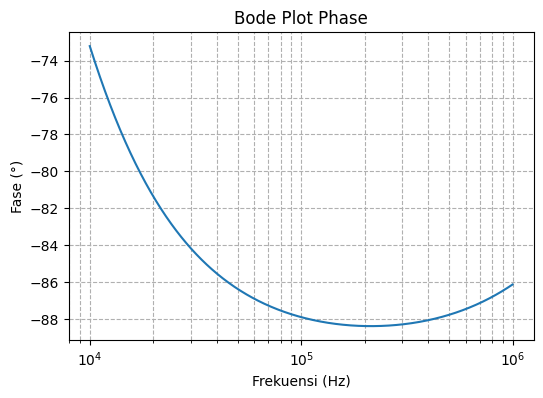

In [30]:
# === 5. Respon Frekuensi ===
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify, symbols

# Ambil s, L1, L2 dan G_s dari workspace Anda
# (Anda sudah mendefinisikan G_s di cell Transfer Function)
# Contoh: from sympy import s, L1, L2, G_s

# Parameter numerik
param_vals = {k:0.6, R1:1.2, R2:1.6, Rload:1e3, Rs:0.0}
L1_val, L2_val = 63.46e-6, 29.2e-6

# Buat fungsi numerik
G_num = lambdify((s, L1, L2),
                 G_s.subs(param_vals),
                 'numpy')

# Sweep frekuensi
freq = np.logspace(4, 6, 500)    # 10^4..10^6 Hz
omega = 2 * np.pi * freq
G_eval = G_num(1j*omega, L1_val, L2_val)

mag_db   = 20 * np.log10(np.abs(G_eval))
phase_deg = np.angle(G_eval, deg=True)

# Plot Bode magnitude
plt.figure(figsize=(6,4))
plt.semilogx(freq, mag_db)
plt.title('Bode Plot Magnitude')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo (dB)')
plt.grid(True, which='both', ls='--')

# Plot Bode phase
plt.figure(figsize=(6,4))
plt.semilogx(freq, phase_deg)
plt.title('Bode Plot Phase')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Fase (°)')
plt.grid(True, which='both', ls='--')
plt.show()

## 6. Respon Waktu

Di bagian ini kita hitung **step response** dari $I_1(t)$ akibat loncatan unit pada sumber, menggunakan `scipy.signal`.

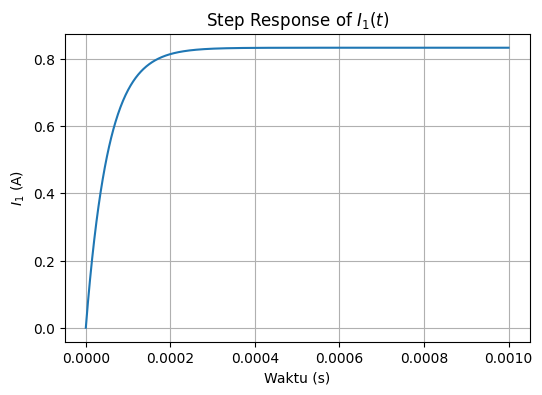

In [33]:
# === 6. Respon Waktu ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import TransferFunction, step
from sympy import Poly

# Dapatkan numerator & denominator simbolik dari G_s
num_sym, den_sym = sp.simplify(G_s.subs(param_vals)).as_numer_denom()

# Substitute L1_val and L2_val into num_sym and den_sym before extracting coefficients
num_sym = num_sym.subs({L1: L1_val, L2: L2_val})
den_sym = den_sym.subs({L1: L1_val, L2: L2_val})

# Ekstrak koefisien polinomial terhadap s
num_coefs = [float(c) for c in Poly(num_sym, s).all_coeffs()]
den_coefs = [float(c) for c in Poly(den_sym, s).all_coeffs()]

# Buat LTI system
sys = TransferFunction(num_coefs, den_coefs)

# Hitung step response
t_out, y_out = step(sys, T=np.linspace(0, 1e-3, 1000))

# Plot
plt.figure(figsize=(6, 4))
plt.plot(t_out, y_out)
plt.title('Step Response of $I_1(t)$')
plt.xlabel('Waktu (s)')
plt.ylabel('$I_1$ (A)')
plt.grid(True)
plt.show()